# 🤖 Model Training Pipeline
## Real Estate Price Prediction

Train LightGBM, XGBoost, and CatBoost models with comprehensive feature engineering

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
import warnings
from pathlib import Path
import sys
from time import time
import re

warnings.filterwarnings('ignore')

# Imports
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from lightgbm import LGBMRegressor
import xgboost as xgb
from catboost import CatBoostRegressor

# Fix path: notebook is in notebooks/02_model_training/, need to go up 2 levels to project root
sys.path.insert(0, str(Path('.').resolve().parent.parent))

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

print('✅ All imports successful!')

## 1. Data Loading & Exploration

In [ ]:
# Load from Supabase (live data)
from pipeline.supabase_handler import fetch_csv_from_supabase

print('Loading data from Supabase...')
df = fetch_csv_from_supabase()
print(f'✅ Loaded {len(df)} records')
print(f'Shape: {df.shape}')
print(f'\nColumns: {list(df.columns)[:15]}...')
print(f'\nTarget (price_vnd) stats:')
print(df['price_vnd'].describe())

## 2. Data Preprocessing & Feature Engineering

In [ ]:
def preprocess_features(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series, dict]:
    """
    Comprehensive preprocessing with feature engineering
    """
    df = df.copy()
    df = df.drop_duplicates()
    
    # 1. Filter outliers
    print('\n[1/5] Filtering outliers...')
    price_b = df['price_vnd'] / 1e9
    df = df[(price_b >= 2.0) & (price_b <= 50.0)]
    if 'area_m2' in df.columns:
        df = df[df['area_m2'].isna() | df['area_m2'].between(15, 500)]
        price_sqm = df['price_vnd'] / 1e6 / df['area_m2']
        df = df[price_sqm.isna() | ((price_sqm >= 30) & (price_sqm <= 800))]
    print(f'  Remaining: {len(df)} records')
    
    # 2. Temporal features
    print('[2/5] Extracting temporal features...')
    if "post_day" in df.columns:
        post_day_dt = pd.to_datetime(df["post_day"])
        df["post_day_year"] = post_day_dt.dt.year
        df["post_day_month"] = post_day_dt.dt.month
        df["post_day_day"] = post_day_dt.dt.day
    
    # 3. Feature engineering
    print('[3/5] Engineering features...')
    if 'width_m' in df.columns and 'length_m' in df.columns:
        df['perimeter_m'] = (df['width_m'] + df['length_m']) * 2
        df['shape_ratio'] = (df['width_m'] + 0.1) / (df['length_m'] + 0.1)
    if 'area_m2' in df.columns and 'num_floors' in df.columns:
        df['area_x_floors'] = df['area_m2'] * df['num_floors']
    if 'area_m2' in df.columns and 'num_bedrooms' in df.columns:
        df['area_x_bedrooms'] = df['area_m2'] * df['num_bedrooms']
        df['area_per_bedroom'] = df['area_m2'] / (df['num_bedrooms'] + 1)
    if 'area_m2' in df.columns:
        df['log_area'] = np.log1p(df['area_m2'])
    if 'distance_to_center_km' in df.columns:
        df['log_distance'] = np.log1p(df['distance_to_center_km'])
    
    # 4. Location & Amenity scores
    print('[4/5] Creating location & amenity scores...')
    if 'distance_to_center_km' in df.columns:
        df['location_score'] = (
            (10 / (df['distance_to_center_km'] + 1)) * 2.0 +
            (10 / (df.get('nearest_school_km', 1) + 1)) * 1.5 +
            (10 / (df.get('nearest_hospital_km', 1) + 1)) * 1.5 +
            (10 / (df.get('nearest_mall_km', 1) + 1)) * 1.0
        )
    df['amenity_score'] = (
        df.get('school_count_3km', 0) * 1.0 +
        df.get('hospital_count_5km', 0) * 1.5 +
        df.get('supermarket_count_3km', 0) * 1.0 +
        df.get('mall_count_3km', 0) * 2.0 +
        df.get('metro_count_5km', 0) * 3.0
    )
    
    # 5. Text features
    print('[5/5] Extracting text features...')
    for col in ['description', 'title']:
        if col in df.columns:
            lower = df[col].astype(str).str.lower()
            df['is_hem_xe_hoi'] = lower.str.contains('hẻm xe hơi|hxh|ô tô|xe hơi').astype(int)
            df['is_mat_tien'] = lower.str.contains('mặt tiền|mặt phố').astype(int)
            df['is_no_hau'] = lower.str.contains('nở hậu').astype(int)
            df['has_noi_that'] = lower.str.contains('nội thất|full|đầy đủ').astype(int)
            df['is_gap'] = lower.str.contains('gấp|giảm giá|cần bán').astype(int)
    
    # Handle missing values
    for col in ['nearest_metro_km', 'nearest_mall_km', 'nearest_supermarket_km']:
        if col in df.columns:
            df[f'{col}_missing'] = df[col].isna().astype(int)
            df[col] = df[col].fillna(999.0)
    
    for col in ['width_m', 'length_m']:
        if col in df.columns:
            df[f'{col}_missing'] = df[col].isna().astype(int)
            df[col] = df[col].fillna(df[col].median())
    
    # Drop non-predictive columns
    drop_cols = ['id', 'price_vnd', 'url', 'link', 'title', 'post_day', 'description',
                 'street', 'ward', 'district', 'locality', 'region',
                 'matched_address', 'old_address', 'lat', 'lon', 'listing_id']
    features_df = df.drop(columns=[c for c in drop_cols if c in df.columns])
    
    # One-hot encode categorical
    cat_cols = features_df.select_dtypes(include=['object', 'category']).columns
    features_df = pd.get_dummies(features_df, columns=cat_cols, dummy_na=True)
    
    # Fix column names for LightGBM
    features_df.columns = features_df.columns.str.replace(r'[\[\]{}"\' :]', '_', regex=True)
    
    metadata = {
        "n_features": features_df.shape[1],
        "features": list(features_df.columns),
    }
    
    return features_df, df['price_vnd'], metadata

print('Preprocessing function defined!')

Preprocessing function defined!


In [ ]:
# Run preprocessing
print('\n' + '='*70)
print('PREPROCESSING START')
print('='*70)
X, y, meta = preprocess_features(df)
print(f"\n✅ Preprocessing complete!")
print(f"  Features shape: {X.shape}")
print(f"  Target shape: {y.shape}")


PREPROCESSING START

[1/5] Filtering outliers...
  Remaining: 2843 records
[2/5] Extracting temporal features...
[3/5] Engineering features...
[4/5] Creating location & amenity scores...
[5/5] Extracting text features...

✅ Preprocessing complete!
  Features shape: (2843, 42)
  Target shape: (2843,)


## 3. Train-Test Split

In [ ]:
# Log transform target
y_log = np.log1p(y)

# Split data
train_idx, test_idx = train_test_split(X.index, test_size=0.2, random_state=42)
X_train, X_test = X.loc[train_idx], X.loc[test_idx]
y_train, y_test = y.loc[train_idx], y.loc[test_idx]
y_log_train, y_log_test = y_log.loc[train_idx], y_log.loc[test_idx]

print(f"\n📊 DATA SPLIT:")
print(f"  Train set: {len(X_train):,} samples")
print(f"  Test set: {len(X_test):,} samples")
print(f"  Features: {X_train.shape[1]}")
print(f"\n  Train price range: {y_train.min()/1e9:.1f}B - {y_train.max()/1e9:.1f}B VND")
print(f"  Test price range: {y_test.min()/1e9:.1f}B - {y_test.max()/1e9:.1f}B VND")


📊 DATA SPLIT:
  Train set: 2,274 samples
  Test set: 569 samples
  Features: 42

  Train price range: 2.2B - 50.0B VND
  Test price range: 2.1B - 50.0B VND


## 4. Model Training

In [ ]:
def mean_absolute_percentage_error(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# Train LightGBM
print('\n' + '='*70)
print('TRAINING LIGHTGBM')
print('='*70)

lgb_params = {
    "n_estimators": 500,
    "max_depth": 8,
    "learning_rate": 0.03,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 42,
    "verbose": -1,
}

t0 = time()
model_lgbm = LGBMRegressor(**lgb_params)
model_lgbm.fit(X_train, y_log_train)
lgbm_time = time() - t0

y_lgbm_pred = np.expm1(model_lgbm.predict(X_test))
y_lgbm_pred = np.clip(y_lgbm_pred, 0, None)

print(f"✅ LightGBM trained in {lgbm_time:.2f}s")


TRAINING LIGHTGBM
✅ LightGBM trained in 4.65s


In [ ]:
# Train XGBoost
print('\n' + '='*70)
print('TRAINING XGBOOST')
print('='*70)

xgb_params = {
    "n_estimators": 500,
    "max_depth": 8,
    "learning_rate": 0.03,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 42,
    "verbosity": 0,
}

t0 = time()
model_xgb = xgb.XGBRegressor(**xgb_params)
model_xgb.fit(X_train, y_log_train, eval_set=[(X_test, y_log_test)], verbose=False)
xgb_time = time() - t0

y_xgb_pred = np.expm1(model_xgb.predict(X_test))
y_xgb_pred = np.clip(y_xgb_pred, 0, None)

print(f"✅ XGBoost trained in {xgb_time:.2f}s")


TRAINING XGBOOST
✅ XGBoost trained in 6.64s


In [ ]:
# Train CatBoost
print('\n' + '='*70)
print('TRAINING CATBOOST')
print('='*70)

cat_params = {
    "iterations": 500,
    "depth": 8,
    "learning_rate": 0.03,
    "subsample": 0.8,
    "random_state": 42,
    "verbose": False,
}

t0 = time()
model_cat = CatBoostRegressor(**cat_params)
model_cat.fit(X_train, y_log_train)
cat_time = time() - t0

y_cat_pred = np.expm1(model_cat.predict(X_test))
y_cat_pred = np.clip(y_cat_pred, 0, None)

print(f"✅ CatBoost trained in {cat_time:.2f}s")


TRAINING CATBOOST
✅ CatBoost trained in 10.30s


## 5. Model Evaluation

In [ ]:
# Evaluate all models
models = {'LightGBM': y_lgbm_pred, 'XGBoost': y_xgb_pred, 'CatBoost': y_cat_pred}
results = {}

print('\n' + '='*70)
print('EVALUATION RESULTS')
print('='*70)

for name, y_pred in models.items():
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    
    results[name] = {'RMSE': rmse, 'MAE': mae, 'R²': r2, 'MAPE': mape}
    
    print(f"\n{name}:")
    print(f"  RMSE:   {rmse/1e9:.2f}B VND")
    print(f"  MAE:    {mae/1e9:.2f}B VND")
    print(f"  R²:     {r2:.4f}")
    print(f"  MAPE:   {mape:.2f}% 🎯")

print('\n' + '='*70)


EVALUATION RESULTS

LightGBM:
  RMSE:   5.28B VND
  MAE:    3.31B VND
  R²:     0.8255
  MAPE:   20.43% 🎯

XGBoost:
  RMSE:   5.49B VND
  MAE:    3.42B VND
  R²:     0.8112
  MAPE:   21.05% 🎯

CatBoost:
  RMSE:   5.26B VND
  MAE:    3.31B VND
  R²:     0.8266
  MAPE:   20.66% 🎯



## 6. Visualization

FileNotFoundError: [Errno 2] No such file or directory: '../models/plots/pred_vs_actual.png'

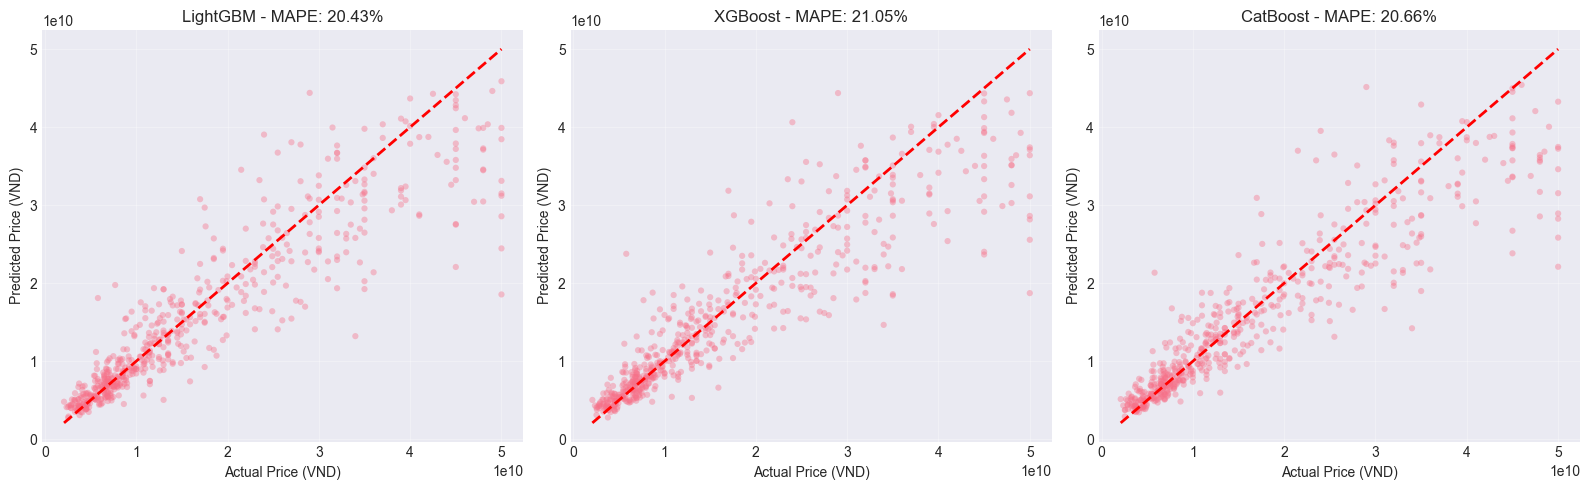

In [ ]:
# Pred vs Actual comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, (name, y_pred) in enumerate(models.items()):
    ax = axes[idx]
    ax.scatter(y_test, y_pred, alpha=0.4, s=20, edgecolors='none')
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    ax.set_xlabel('Actual Price (VND)')
    ax.set_ylabel('Predicted Price (VND)')
    ax.set_title(f'{name} - MAPE: {results[name]["MAPE"]:.2f}%')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../models/plots/pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: pred_vs_actual.png')

In [ ]:
# Feature importance
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# LightGBM
lgbm_imp = model_lgbm.feature_importances_
top_lgbm_idx = np.argsort(lgbm_imp)[-15:]
axes[0].barh(range(len(top_lgbm_idx)), lgbm_imp[top_lgbm_idx], color='steelblue')
axes[0].set_yticklabels([X.columns[i] for i in top_lgbm_idx])
axes[0].set_title('Top 15 LightGBM Feature Importance')
axes[0].set_xlabel('Importance')

# XGBoost
xgb_imp = model_xgb.feature_importances_
top_xgb_idx = np.argsort(xgb_imp)[-15:]
axes[1].barh(range(len(top_xgb_idx)), xgb_imp[top_xgb_idx], color='coral')
axes[1].set_yticklabels([X.columns[i] for i in top_xgb_idx])
axes[1].set_title('Top 15 XGBoost Feature Importance')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('../models/plots/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: feature_importance.png')

## 7. Summary & Next Steps

In [ ]:
# Summary table
results_df = pd.DataFrame(results).T
results_df['RMSE (Billions)'] = results_df['RMSE'] / 1e9
results_df['MAE (Billions)'] = results_df['MAE'] / 1e9
print('\n' + '='*80)
print('MODEL COMPARISON SUMMARY')
print('='*80)
print(results_df[['RMSE (Billions)', 'MAE (Billions)', 'R²', 'MAPE']].to_string())
print('\n' + '='*80)

best_mape_model = results_df['MAPE'].idxmin()
best_mape = results_df['MAPE'].min()
print(f"\n🏆 Best Model: {best_mape_model} (MAPE: {best_mape:.2f}%)")
print(f"   Target: MAPE < 10% - {'✅ ACHIEVED!' if best_mape < 10 else '⚠️ Need improvement'}")

print(f"\n📊 Next Steps:")
print(f"  1. Save best model to production")
print(f"  2. Deploy to web application")
print(f"  3. Build BI dashboard for market trends")
print(f"  4. Hyperparameter tuning for further improvement")
print(f"\n" + '='*80)